<a href="https://colab.research.google.com/github/hasselmanneduarda-wq/bioestat-2026/blob/main/tarefa5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tarefa 5 - Semana 3

##Maria Eduarda Silva Hasselmann - 17100517
##Raissa Lara Pinheiro - 16939302


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [87]:
sns.set_theme(style="whitegrid")

dados = pd.read_excel("Tarefa_Semana3.xlsx")

print("Primeiras linhas dos dados:")
display(df.head())

print("\nDimensão do conjunto de dados:")
print(df.shape)



Primeiras linhas dos dados:


,Bloco,Tratamento,Recipiente,Explante,Brotos,Folhas,Tratamento_nome
0,1,0,1,1,2,6,0 mg/L (Controle)
1,1,0,1,2,1,8,0 mg/L (Controle)
2,1,0,1,3,0,0,0 mg/L (Controle)
3,1,0,1,4,1,0,0 mg/L (Controle)
4,1,0,1,5,2,0,0 mg/L (Controle)



Dimensão do conjunto de dados:
(120, 7)


In [88]:
# Pergunta 1

for variavel in ["Brotos", "Folhas"]:
    Q1 = df[variavel].quantile(0.25)
    Q3 = df[variavel].quantile(0.75)
    IQR = Q3 - Q1

    atipicos = df[
        (df[variavel] < Q1 - 1.5*IQR) |
        (df[variavel] > Q3 + 1.5*IQR)
    ]

    print(f"\n{variavel}")
    print("Mínimo:", df[variavel].min())
    print("Máximo:", df[variavel].max())
    print("Atípicos:", atipicos[variavel].tolist())


Brotos
Mínimo: 0
Máximo: 6
Atípicos: [6]

Folhas
Mínimo: 0
Máximo: 46
Atípicos: [46]


#Pergunta 1 - Resposta

## Foram identificadas duas observações atípicas, no número de brotos, o valor máximo foi 6, visto no tratamento com 1 mg/L de BAP. Para o número de folhas, o valor máximo foi de 46, observado no tratamento com 3 mg/L de BAP. Os valores mínimos foram 0 para brotos e para folhas. Os valores de máximo e mínimo representam, respectivamente, o menor e o maior número de brotos ou folhas observado entre todos os explantes avaliados.

In [89]:
# Pergunta 2
quartis = pd.DataFrame({
    "Q2 (Mediana)": [
        df["Brotos"].quantile(0.50),
        df["Folhas"].quantile(0.50)
    ],
    "Q3": [
        df["Brotos"].quantile(0.75),
        df["Folhas"].quantile(0.75)
    ]
}, index=["Brotos", "Folhas"])

print("2º e 3º quartis:")
display(quartis)

2º e 3º quartis:


,Q2 (Mediana),Q3
Brotos,2.0,2.0
Folhas,10.0,18.0


# Pergunta 2 - Resposta

## Nos brotos, a mediana é 2, indicando que aproximadamente metade dos explantes apresentou até 2 brotos e metade apresentou pelo menos 2 brotos. O terceiro quartil também foi 2, mostrando que aproximadamente 75% das observações apresentaram até 2 brotos. Nas folhas, a mediana foi 10, enquanto o terceiro quartil foi 18, aproximadamente 50% dos explantes apresentaram até 10 folhas e 75% apresentaram até 18 folhas.

In [90]:
# Pergunta 3

nomes_tratamentos = {
    0: "0 mg/L (Controle)",
    1: "1 mg/L",
    2: "2 mg/L",
    3: "3 mg/L"
}

df["Tratamento_nome"] = df["Tratamento"].map(nomes_tratamentos)

medias = df.groupby("Tratamento_nome")[["Brotos", "Folhas"]].mean()

print("Número médio de brotos e folhas por explante:")
display(medias.round(2))

Número médio de brotos e folhas por explante:


,Brotos,Folhas
Tratamento_nome,,
0 mg/L (Controle),0.93,5.40
1 mg/L,1.87,15.00
2 mg/L,2.27,11.70
3 mg/L,1.70,9.07


# Pergunta 3 - Resposta

## O tratamento com 2 mg/L apresentou a maior média de brotos no geral, com 2,27 brotos por explante. Para folhas, a maior média foi observada com 1 mg/L, com 15 folhas por explante. O controle apresentou as menores médias nas duas variáveis.

In [39]:
# Pergunta 4 - Variabilidade

variabilidade = df.groupby("Tratamento_nome")[["Brotos", "Folhas"]].std()

variabilidade.columns = ["Desvio-padrão - Brotos", "Desvio-padrão - Folhas"]

display(variabilidade.round(3))

,Desvio-padrão - Brotos,Desvio-padrão - Folhas
Tratamento_nome,,
0 mg/L (Controle),0.828,6.371
1 mg/L,1.332,11.126
2 mg/L,1.507,9.064
3 mg/L,1.466,11.129


#Pergunta 4 - Resposta

##Os tratamentos de 2 mg/L de BAP apresentaram maior variabilidade sobre o número de brotos, enquanto o tratamento de 3 mg/L mostrou uma maior variabilidade para número de folhas.

In [91]:
# Pergunta 5

from scipy.stats import ttest_ind
import pandas as pd

controle = df[df["Tratamento"] == 0]

resultados_testes = []

for tratamento in [1, 2, 3]:

    grupo = df[df["Tratamento"] == tratamento]

    t_brotos, p_brotos = ttest_ind(
        controle["Brotos"],
        grupo["Brotos"],
        equal_var=False
    )

    t_folhas, p_folhas = ttest_ind(
        controle["Folhas"],
        grupo["Folhas"],
        equal_var=False
    )

    resultados_testes.append({
        "Tratamento": f"{tratamento} mg/L",
        "t Folhas": t_folhas,
        "p Folhas": p_folhas,
        "Resultado Folhas": "Significativo" if p_folhas < 0.05 else "Não significativo",
        "t Brotos": t_brotos,
        "p Brotos": p_brotos,
        "Resultado Brotos": "Significativo" if p_brotos < 0.05 else "Não significativo"
    })

resultados_testes_df = pd.DataFrame(resultados_testes)

column_order = [
    "Tratamento",
    "t Folhas",
    "p Folhas",
    "Resultado Folhas",
    "t Brotos",
    "p Brotos",
    "Resultado Brotos"
]

resultados_testes_df = resultados_testes_df[column_order]

print("Tabela de Comparação do Controle com Outros Tratamentos:")
display(resultados_testes_df.round(4))


Tabela de Comparação do Controle com Outros Tratamentos:


,Tratamento,t Folhas,p Folhas,Resultado Folhas,t Brotos,p Brotos,Resultado Brotos
0,1 mg/L,-4.1011,0.0002,Significativo,-3.2595,0.0020,Significativo
1,2 mg/L,-3.1146,0.0030,Significativo,-4.2474,0.0001,Significativo
2,3 mg/L,-1.5661,0.1242,Não significativo,-2.4947,0.0163,Significativo


# Pergunta 5 - Resposta

## Houve uma grande ddiferença  entre o controle e as doses de 1, 2 e 3 mg/L para o número de brotos. Para o número de folhas, houve diferença entre o controle e as doses de 1 e 2 mg/L, mas não entre o controle e 3 mg/L, considerando uma significância de 5%.

In [92]:
# Pergunta 6


media_folhas = df.groupby("Tratamento_nome")["Folhas"].mean().sort_values(
    ascending=False
)

print("Média de folhas por tratamento:")
display(media_folhas.round(2))


Média de folhas por tratamento:


,Folhas
Tratamento_nome,
1 mg/L,15.00
2 mg/L,11.70
3 mg/L,9.07
0 mg/L (Controle),5.40


# Pergunta 6 - Resposta

## O tratamento com maior média de folhas foi de 1 mg/L, com 15 folhas. O tratamento com menos média de folhas foi o controle, com 5.4.


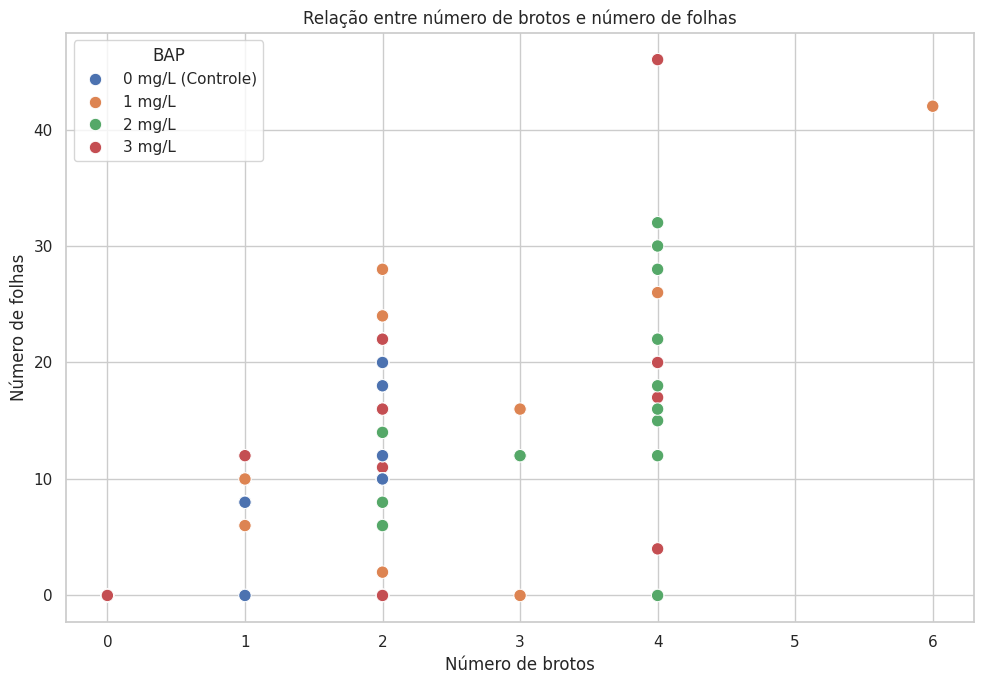

Correlação entre brotos e folhas:


,Brotos,Folhas
Brotos,1.0,0.7
Folhas,0.7,1.0



Correlação entre brotos e folhas p/ tratamento:


,0
Tratamento_nome,
0 mg/L (Controle),0.70
1 mg/L,0.75
2 mg/L,0.76
3 mg/L,0.60


In [93]:
# Pergunta 7

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Brotos",
    y="Folhas",
    hue="Tratamento_nome",
    s=80
)

plt.title("Relação entre número de brotos e número de folhas")
plt.xlabel("Número de brotos")
plt.ylabel("Número de folhas")
plt.legend(title="BAP")
plt.tight_layout()
plt.show()

broto_x_folha = df[["Brotos", "Folhas"]].corr()
print("Correlação entre brotos e folhas:")
display(broto_x_folha.round(2))

correlacao_tratamento = df.groupby("Tratamento_nome").apply(
    lambda x: x["Brotos"].corr(x["Folhas"]),
    include_groups=False
)

print("\nCorrelação entre brotos e folhas p/ tratamento:")
display(correlacao_tratamento.round(2))


max_brotos_treatment = medias["Brotos"].idxmax()
max_brotos_value = medias["Brotos"].max()

max_folhas_treatment = medias["Folhas"].idxmax()
max_folhas_value = medias["Folhas"].max()



#Pergunt 7 - Resposta

##O tratamento com maior média de brotos é o de 2 mg/L (com 2.27 brotos). Porém, esse tratamento não tem a maior média de folhas. Essa média é encontrada no tratamento de 1 mg/L (15 folhas). O tratamento de 2 mg/L tem 11.7 folhas, moderado em comparação com a maior média. Assim, o tratamento de 2 mg/L de BAP pode ser considerado o com maior brotação, mas sem melhporar a quantidade de folhas em comparação com o tratamento de 1 mg/L, que tem menos brotos, mas tem  mais folhas.

In [94]:
# Pergunta 8
def amplitude(x):
    return x.max() - x.min()

estatisticas = df.groupby("Tratamento_nome").agg(
    Amp_Brotos=("Brotos", amplitude),
    Var_Brotos=("Brotos", "var"),
    DP_Brotos=("Brotos", "std"),
    Amp_Folha=("Folhas", amplitude),
    Var_Folha=("Folhas", "var"),
    DP_Folha=("Folhas", "std")
)

estatisticas_transposed = estatisticas.transpose()
display(estatisticas_transposed.round(2))

Tratamento_nome,0 mg/L (Controle),1 mg/L,2 mg/L,3 mg/L
Amp_Brotos,2.00,6.00,4.00,4.00
Var_Brotos,0.69,1.77,2.27,2.15
DP_Brotos,0.83,1.33,1.51,1.47
Amp_Folha,20.00,42.00,32.00,46.00
Var_Folha,40.59,123.79,82.15,123.86
DP_Folha,6.37,11.13,9.06,11.13


# Pergunta 8 - Resposta

##O tratamento com maior desvio-padrão de brotos foi de 2 mg/L e o com maior desvio-padrão de folhas foi de 3 mg/L

In [95]:
#Pergunta 9

def coeficiente_variacao(x):
    media = x.mean()
    desvio = x.std()

    if media == 0:
        return np.nan

    return (desvio / media) * 100

cv = df.groupby("Tratamento_nome").agg(
    CV_Brotos=("Brotos", coeficiente_variacao),
    CV_Folhas=("Folhas", coeficiente_variacao)
)

print("Coeficiente de variação (%):")
display(cv.round(2))

Coeficiente de variação (%):


,CV_Brotos,CV_Folhas
Tratamento_nome,,
0 mg/L (Controle),88.68,117.99
1 mg/L,71.37,74.17
2 mg/L,66.49,77.47
3 mg/L,86.22,122.75


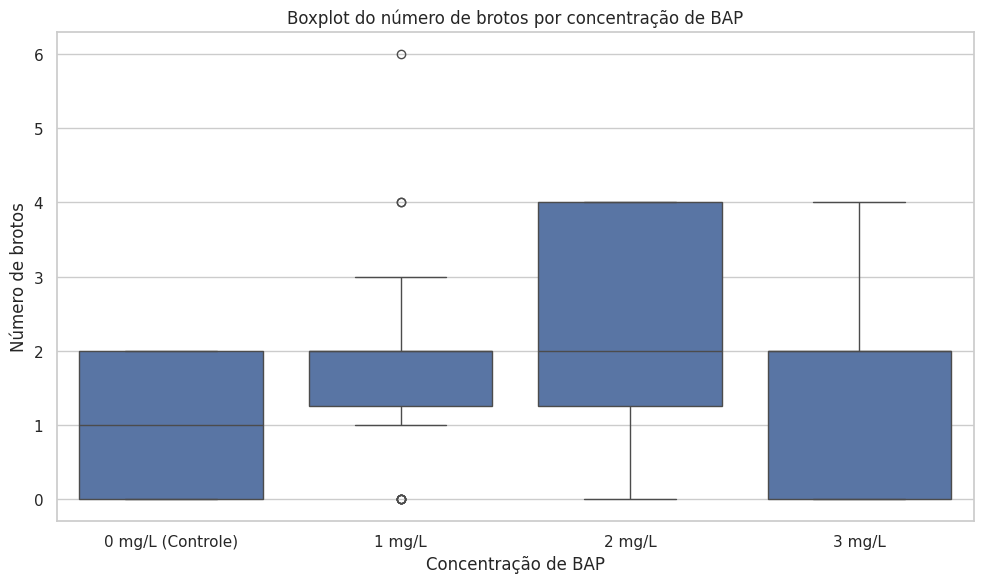

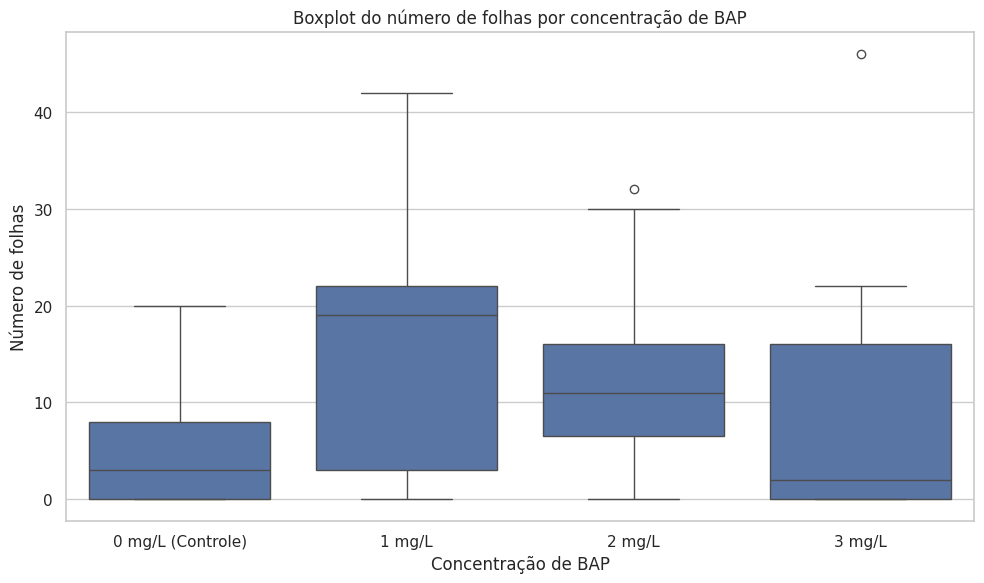

In [96]:
# Pergunta 10

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Tratamento_nome",
    y="Brotos"
)

plt.title("Boxplot do número de brotos por concentração de BAP")
plt.xlabel("Concentração de BAP")
plt.ylabel("Número de brotos")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Tratamento_nome",
    y="Folhas"
)

plt.title("Boxplot do número de folhas por concentração de BAP")
plt.xlabel("Concentração de BAP")
plt.ylabel("Número de folhas")
plt.tight_layout()
plt.show()

# Pergunta 10 - Resposta

##Nos boxplots de brotos, é possível perceber que a mediana geral está próxima de 2 brotos e o tratamento de 2 mg/L apresenta maior dispersão, enquanto o valor 6 brotos, em 1 mg/L, é um possível valor atípico.

##Nos boxplots de folhas, a mediana geral é 10 folhas. A concentração 1 mg/L apresenta uma distribuição com valores mais altos e a concentração de 3 mg/L apresenta uma grande dispersão e o valor 46 folhas, em 3 mg/L, aparece como possível valor atípico.

# Pergunta 11 - Resposta

##Para brotos, os dados de 2 mg/L são mais concentrados em torno da distribuição central, mesmo que apresentem variabilidade elevada. No caso das folhas, o tratamento de 3 mg/L tem maior dispersão e maior assimetria positiva, podendo ser influenciada também pelo valor 46 folhas. O tratamento de 1 mg/L apresenta uma distribuição de folhas mais equilibrada e mesmo que sua amplitude seja maior seu CV é menor que os demais tratamentos de folhas.